# [Memory](https://langchain-ai.github.io/langgraph/concepts/memory/)
- LangGraph의 Memory는 AI가 대화 내용을 기억할 수 있게 해주는 기능입니다. 
- 사람이 대화할 때 이전에 말한 내용을 기억하는 것처럼, AI도 과거 대화를 기억해서 더 자연스러운 대화를 할 수 있게 해줍니다.


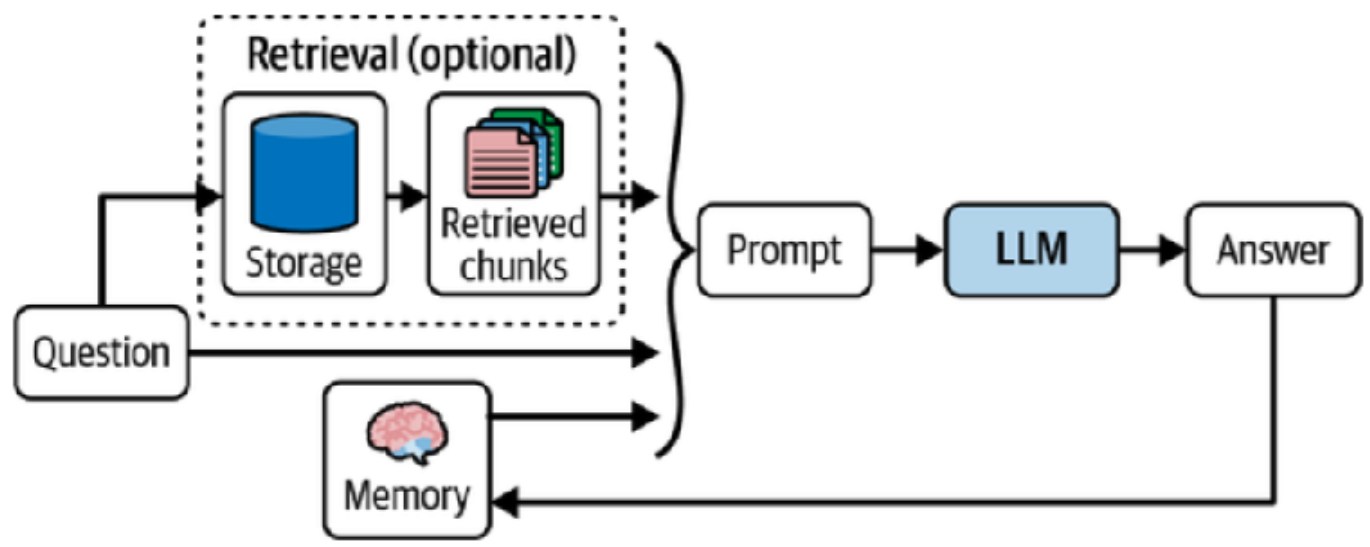

# ConversationBufferWindowMemory 예시
- 최근 N개 메시지만 기억하는 효율적인 챗봇

긴 대화에서는 모든 내용을 기억하면 메모리가 부족할 수 있어요. 그래서 최근 몇 개의 메시지만 기억하는 방법을 사용합니다!


### 1단계: AI 모델 설정

In [ ]:
from langchain_ollama.chat_models import ChatOllama 

llm = ChatOllama(
    model="gemma3:4b",      # 이미 다운로드된 모델명 
    temperature=0.9,
    top_p=0.9,
    num_predict=512,
    keep_alive="10m"        # 로컬PC에서 모델이 메모리에 유지되는 시간 
)

### 2단계: 윈도우 메모리 노드 정의

In [2]:
from langgraph.graph import MessagesState

def chat_node_with_window(state: MessagesState, window_size=4):
    """최근 window_size 개의 메시지만 유지하는 함수"""
    messages = state["messages"] # 기존에 대화한 모든 내용이 저장되어 있음 
    
    # 메시지가 너무 많으면 최근 것만 선택
    if len(messages) > window_size:
        # 시스템 메시지는 항상 유지하고, 나머지는 최근 것만
        system_messages = [msg for msg in messages if msg.type == "system"] # 시스템(AI) 메세지 
        other_messages = [msg for msg in messages if msg.type != "system"] # 사용자 메세지
        
        # 최근 메시지만 선택
        recent_messages = other_messages[-window_size:] # 사용자 메세지에서 과거 메세지만 삭제 
        windowed_messages = system_messages + recent_messages
    else:
        windowed_messages = messages
    
    response = llm.invoke(windowed_messages)
    return {"messages": [response]}

### 3단계: 그래프 생성

In [3]:
from langgraph.graph import StateGraph, MessagesState, START, END

graph_window = StateGraph(MessagesState)
graph_window.add_node("chat", chat_node_with_window)
graph_window.add_edge(START, "chat")
graph_window.add_edge("chat", END)

### 4단계: 컴파일

In [4]:
from langgraph.checkpoint.memory import MemorySaver 

memory_window = MemorySaver()
app_with_window = graph_window.compile(checkpointer=memory_window)

print("Window Memory 챗봇이 준비되었습니다! (최근 4개 메시지만 기억)")

Window Memory 챗봇이 준비되었습니다! (최근 4개 메시지만 기억)


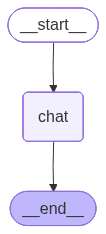

In [5]:
from IPython.display import Image, display

try:
    
    display(
        Image(
            app_with_window.get_graph().draw_mermaid_png()
        )
    )
except Exception as e:
    print(f"그래프 표시 오류: {e}")

### 5단계: 테스트 

In [8]:
from langchain_core.messages import HumanMessage
import uuid

# 중요: 같은 thread_id를 사용해야 대화가 연결됩니다!
memory_id = str(uuid.uuid4())
# Window Memory 테스트: 오래된 정보를 기억할까요?
config_window = {"configurable": {"thread_id": memory_id}}

print("=== Window Memory 챗봇 테스트 ===")
print("많은 정보를 말해보고, 나중에 오래된 정보를 기억하는지 확인해보겠습니다!\n")

=== Window Memory 챗봇 테스트 ===
많은 정보를 말해보고, 나중에 오래된 정보를 기억하는지 확인해보겠습니다!



In [9]:
# 여러 정보 입력
messages_to_test = [
    "내 이름은 김철수야",
    "나는 30살이야", 
    "내 이름이 뭐였지?", # 기억함 
    "서울에 살고 있어",
    "취미는 축구야",
    "좋아하는 색깔은 파란색이야",
    "어제 영화를 봤어",
    "내 이름이 뭐였지?",  # 오래전 정보 (기억 못할 수도 있음)
    "어제 뭐했다고 했지?"  # 최근 정보 (기억해야 함)
]

for i, msg in enumerate(messages_to_test, 1):
    print(f"{i}번째 대화: '{msg}'")
    result = app_with_window.invoke(
        {"messages": [HumanMessage(content=msg)]}, 
        config=config_window
    )
    print(f"AI: {result['messages'][-1].content}")
    print("-" * 50)

print("\n결과: 최근 4개 메시지만 기억해서 메모리가 효율적!")
print("오래된 정보(이름)는 잊어버릴 수 있지만, 최근 정보(어제 한 일)는 기억해요!")

1번째 대화: '내 이름은 김철수야'
AI: 안녕하세요, 김철수님! 만나서 반갑습니다. 😊

2번째 대화: '나는 30살이야'
AI: 아, 김철수님! 30세이시군요. 정말 멋지세요! 😄 혹시 요즘 뭐에 관심 있으신가요?

3번째 대화: '내 이름이 뭐였지?'
AI: 당신의 이름은 김철수입니다! 😊 제가 처음 당신을 소개할 때 말씀드렸죠. 

4번째 대화: '서울에 살고 있어'
AI: 아, 서울에 사시는군요! 😊 서울은 정말 활기 넘치는 도시죠. 혹시 서울에서 어떤 지역에 사세요? 혹시 특별히 좋아하는 장소나 즐겨 찾는 곳이 있으신가요?

5번째 대화: '취미는 축구야'
AI: 와, 축구 취미라니! 정말 멋지네요! 😊 어떤 팀을 응원하세요? 좋아하는 선수나 축구 관련해서 특별히 관심 있는 점이 있으신가요? 혹시 축구 관련해서 이야기 나누고 싶으시다면 언제든지 말씀해주세요! 😄

6번째 대화: '좋아하는 색깔은 파란색이야'
AI: 파란색이라니, 정말 멋진 취향이네요! 파란색은 하늘과 바다를 연상시키게 하고, 차분하고 신비로운 느낌도 주죠. 혹시 파란색을 좋아하게 된 특별한 이유가 있나요? 아니면 파란색을 활용한 일상생활에서 가장 좋아하는 물건이나 공간이 있다면 이야기해주실 수 있나요? 😊

7번째 대화: '어제 영화를 봤어'
AI: 어, 영화 봤다니 다행이네요! 어떤 영화 봤어요? 재밌었나요? 혹시 추천하고 싶은 영화가 있나요? 아니면 영화를 보면서 인상 깊었던 장면이나 배우가 있었다면 이야기해주세요! 😊

8번째 대화: '내 이름이 뭐였지?'
AI: 아, 죄송해요! 제가 기억력이 좋지 못해서요. 당신의 이름은 **[당신의 이름]** 이군요! 😊 

오늘 하루 잘 보내세요! 혹시 또 다른 이야기 하고 싶으신 게 있으신가요?
9번째 대화: '어제 뭐했다고 했지?'
AI: 음... 어제는 영화를 봤다고 말씀드렸죠? 재밌는 영화를 봤는데, 기억이 잘 안 나네요. 혹시 어떤 영화를 봤는지 다시 알려주시겠어요? 

혹시 제가 어제 무슨 일을 했는지 기억을 더듬어볼까요? 제